# mdCATH Data Exploration

Step-by-step walkthrough of the raw HDF5 data and each transform applied to produce the `MDCathToMinifoldDataset` output.

**Example protein:** `1a0aA00`

In [25]:
## Step 0: Imports and paths
import h5py
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path

H5_PATH = Path("../data/mdcath/data/mdcath_dataset_1a0aA00.h5")
DOMAIN_ID = "1a0aA00"

print(f"File exists: {H5_PATH.exists()}")
print(f"File size: {H5_PATH.stat().st_size / 1e6:.1f} MB")

File exists: True
File size: 300.4 MB


In [26]:
## Step 1: Raw HDF5 structure — what's inside the file?
with h5py.File(H5_PATH, "r") as f:
    domain = f[DOMAIN_ID]

    # --- Top-level key = CATH domain ID ---
    # Each HDF5 file contains exactly ONE protein domain, identified by its CATH ID.
    # CATH is a protein structure classification: Class → Architecture → Topology → Homology
    # "1a0aA00" = PDB ID "1a0a", chain "A", CATH domain "00"
    print(f"=== HDF5 top-level key: '{DOMAIN_ID}' ===")
    print(f"  This is the CATH domain ID (one per file)")
    print(f"  PDB ID: {DOMAIN_ID[:4]}, Chain: {DOMAIN_ID[4]}, Domain: {DOMAIN_ID[5:]}\n")

    # --- Domain-level datasets (topology / per-atom metadata) ---
    # These describe the STATIC structure of the protein — same for every MD frame.
    print("=== Domain-level datasets (shared across all frames) ===")
    for key in sorted(domain.keys()):
        obj = domain[key]
        if isinstance(obj, h5py.Dataset):
            print(f"  {key:20s}  shape={str(obj.shape):15s}  dtype={obj.dtype}")

    print()
    print("  Meaning of each dataset:")
    print("    z                  Atomic number per atom (1=H, 6=C, 7=N, 8=O, 16=S)")
    print("    resid              Residue index per atom (which residue each atom belongs to)")
    print("    resname            Residue name per atom (3-letter code, e.g. 'MET', 'ALA')")
    print("    chain              Chain ID per atom (always same chain in a single domain)")
    print("    element            Element symbol per atom ('C', 'N', 'O', 'S', 'H')")
    print("    pdb                Full PDB file text (all atoms + CONECT records)")
    print("    pdbProteinAtoms    PDB text for protein atoms only (what we parse atom names from)")
    print("    psf                PSF topology file text (bonds, angles — for MD simulations)")
    print()
    print("  Note: z, resid, resname, chain, element all have shape (1010,) = one entry PER ATOM")
    print("  Note: there is NO 'name' (atom name) array! We must parse names from the PDB text.")

    # --- Temperature groups ---
    temps = sorted([k for k in domain.keys() if isinstance(domain[k], h5py.Group)])
    print(f"\n=== Temperature groups: {temps} ===")
    print("  Each temperature is a separate MD simulation temperature in Kelvin.")
    print("  Higher temps → more protein flexibility/unfolding.")

    # --- Show trajectory hierarchy for ONE temp/replica ---
    temp0, repl0 = temps[0], "0"
    print(f"\n=== Trajectory datasets (showing {temp0}K / replica {repl0}) ===")
    for dset_name in sorted(domain[temp0][repl0].keys()):
        dset = domain[temp0][repl0][dset_name]
        print(f"  {dset_name:20s}  shape={str(dset.shape):20s}  dtype={dset.dtype}")
    
    print()
    print("  Meaning of each trajectory dataset:")
    print("    coords             Atom positions per frame: (n_frames, n_atoms, 3) in Angstroms")
    print("    forces             Forces on each atom per frame: (n_frames, n_atoms, 3)")
    print("    box                Simulation box vectors: (3, 3) — periodic boundary conditions")
    print("    dssp               Secondary structure assignment per frame: (n_frames, n_residues)")
    print("                       H=helix, E=sheet, C=coil, etc. (DSSP algorithm)")  
    print("    rmsd               RMSD from starting structure per frame: (n_frames,)")
    print("    rmsf               Root-mean-square fluctuation per residue: (n_residues,)")
    print("    gyrationRadius     Radius of gyration per frame: (n_frames,) — protein compactness")

    # --- Summary ---
    n_temps = len(temps)
    n_repls = len(domain[temp0].keys())
    sample_nframes = domain[temp0][repl0]["coords"].shape[0]
    n_atoms = domain[temp0][repl0]["coords"].shape[1]
    print(f"\n=== Summary ===")
    print(f"  {n_temps} temperatures × {n_repls} replicas = {n_temps * n_repls} trajectories")
    print(f"  ~{sample_nframes} frames per trajectory, {n_atoms} atoms per frame")
    print(f"  Total: ~{n_temps * n_repls * sample_nframes:,} frames of MD simulation")

=== HDF5 top-level key: '1a0aA00' ===
  This is the CATH domain ID (one per file)
  PDB ID: 1a0a, Chain: A, Domain: 00

=== Domain-level datasets (shared across all frames) ===
  chain                 shape=(1010,)          dtype=object
  element               shape=(1010,)          dtype=object
  pdb                   shape=()               dtype=object
  pdbProteinAtoms       shape=()               dtype=object
  psf                   shape=()               dtype=object
  resid                 shape=(1010,)          dtype=int64
  resname               shape=(1010,)          dtype=object
  z                     shape=(1010,)          dtype=int64

  Meaning of each dataset:
    z                  Atomic number per atom (1=H, 6=C, 7=N, 8=O, 16=S)
    resid              Residue index per atom (which residue each atom belongs to)
    resname            Residue name per atom (3-letter code, e.g. 'MET', 'ALA')
    chain              Chain ID per atom (always same chain in a single domain)
 

In [27]:
## Step 2: Inspect per-atom metadata (domain level)
# These arrays all have shape (n_atoms,) — one entry PER ATOM in the protein.
# They describe the TOPOLOGY: which atom is which, what residue it belongs to, etc.
# This is constant across all MD frames (atoms don't change identity during simulation).

with h5py.File(H5_PATH, "r") as f:
    domain = f[DOMAIN_ID]
    z_raw = domain["z"][:]              # Atomic number per atom
    resid_raw = domain["resid"][:]      # Residue index per atom
    resname_raw = domain["resname"][:]  # Residue name per atom (bytes)
    pdb_text = domain["pdbProteinAtoms"][()].decode("utf-8")

# --- Atomic numbers (z) ---
print("=== z: Atomic numbers ===")
print(f"  One integer per atom — identifies the ELEMENT")
print(f"  shape: {z_raw.shape}  ({len(z_raw)} atoms total)")
print(f"  unique: {np.unique(z_raw)}  →  1=H (hydrogen), 6=C (carbon), 7=N (nitrogen), 8=O (oxygen), 16=S (sulfur)")
print(f"  hydrogens (z=1): {(z_raw == 1).sum()}, heavy atoms (z>1): {(z_raw > 1).sum()}")

# --- Residue IDs (resid) ---
# IMPORTANT: resid has the SAME shape as z — it's PER-ATOM, not per-residue!
# Multiple atoms share the same resid because they belong to the same amino acid.
print(f"\n=== resid: Residue index per atom ===")
print(f"  shape: {resid_raw.shape}  (same as z — one per ATOM, not per residue)")
print(f"  range: {resid_raw.min()} – {resid_raw.max()}  →  {len(np.unique(resid_raw))} unique residues")
print(f"  first 23 atoms all belong to residue 0 (MET has ~23 atoms including H):")
print(f"    resids: {resid_raw[:23]}")

# --- Residue names (resname) ---  
# Also per-atom — all atoms in one residue share the same name.
resname_decoded = np.array([x.decode("utf-8") if isinstance(x, bytes) else x for x in resname_raw])
print(f"\n=== resname: Residue name per atom ===")
print(f"  shape: {resname_decoded.shape}  (per-atom, same residue → same name)")
print(f"  unique names: {list(np.unique(resname_decoded))}")
print(f"  Note: 'HSD' is CHARMM's name for Histidine (standard: HIS)")

# --- PDB text ---
# This is a PDB-format string containing ALL protein atoms.
# We need this because the HDF5 does NOT store atom names directly.
pdb_lines = pdb_text.splitlines()
atom_lines = [l for l in pdb_lines if l.startswith("ATOM")]
print(f"\n=== pdbProteinAtoms: PDB-format text ===")
print(f"  {len(pdb_lines)} lines total, {len(atom_lines)} ATOM records")
print(f"\n  Example PDB ATOM line:")
print(f"    {atom_lines[0]}")
print()
print("  PDB ATOM line format (fixed-width columns):")
print("  ┌──────┬─────┬──────┬────────┬───┬─────┬───────────────────────────┬──────┬──────┬─────┬─────┐")
print("  │Record│Atom#│ Name │ResName │Chn│ResID│    X         Y         Z  │ Occ  │BFact │ Seg │Elem │")
print("  │ 1-6  │7-11 │12-16 │ 17-20  │21 │22-26│   31-38    39-46    47-54 │55-60 │61-66 │73-76│77-78│")
print("  └──────┴─────┴──────┴────────┴───┴─────┴───────────────────────────┴──────┴──────┴─────┴─────┘")
print(f"    ATOM      1  CAY  MET  0   0     -13.223 -22.589  20.858  0.00  0.00      P0   C")
print(f"    ^^^^      ^  ^^^  ^^^      ^     ^^^^^^^ ^^^^^^^ ^^^^^^^  ^^^^  ^^^^      ^^   ^")
print(f"    Record  Num  Name Res    ResID      X       Y       Z     Occ   Bfac     Seg  Elem")
print()
print("  Column 12-16 (Name) is how we extract atom names like 'CA', 'CB', 'N', 'O', etc.")
print("  Occupancy (Occ) and B-factor (Bfac) are 0.00 here — not relevant for MD trajectories.")

=== z: Atomic numbers ===
  One integer per atom — identifies the ELEMENT
  shape: (1010,)  (1010 atoms total)
  unique: [ 1  6  7  8 16]  →  1=H (hydrogen), 6=C (carbon), 7=N (nitrogen), 8=O (oxygen), 16=S (sulfur)
  hydrogens (z=1): 508, heavy atoms (z>1): 502

=== resid: Residue index per atom ===
  shape: (1010,)  (same as z — one per ATOM, not per residue)
  range: 0 – 62  →  63 unique residues
  first 23 atoms all belong to residue 0 (MET has ~23 atoms including H):
    resids: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

=== resname: Residue name per atom ===
  shape: (1010,)  (per-atom, same residue → same name)
  unique names: [np.str_('ALA'), np.str_('ARG'), np.str_('ASN'), np.str_('CYS'), np.str_('GLN'), np.str_('GLU'), np.str_('GLY'), np.str_('HSD'), np.str_('ILE'), np.str_('LEU'), np.str_('LYS'), np.str_('MET'), np.str_('PRO'), np.str_('SER'), np.str_('THR'), np.str_('TRP'), np.str_('TYR'), np.str_('VAL')]
  Note: 'HSD' is CHARMM's name for Histidine (standard: HIS)

=

=== Coordinates dataset ===
  shape: (440, 1010, 3)  →  (n_frames, n_atoms, xyz)
  dtype: float32

=== Frame 0 ===
  shape: (1010, 3)
  coord range X: [50.5, 85.8]
  coord range Y: [-8.1, 38.6]
  coord range Z: [-18.8, 13.4]
  units: Angstroms (mdCATH stores in Å)
  first 5 atoms:
[[57.910004   3.24      -6.84     ]
 [58.81       3.6200001 -6.3000007]
 [56.95       3.6800003 -6.4900007]
 [58.14       3.46      -7.9      ]
 [57.770004   1.7500001 -6.79     ]]


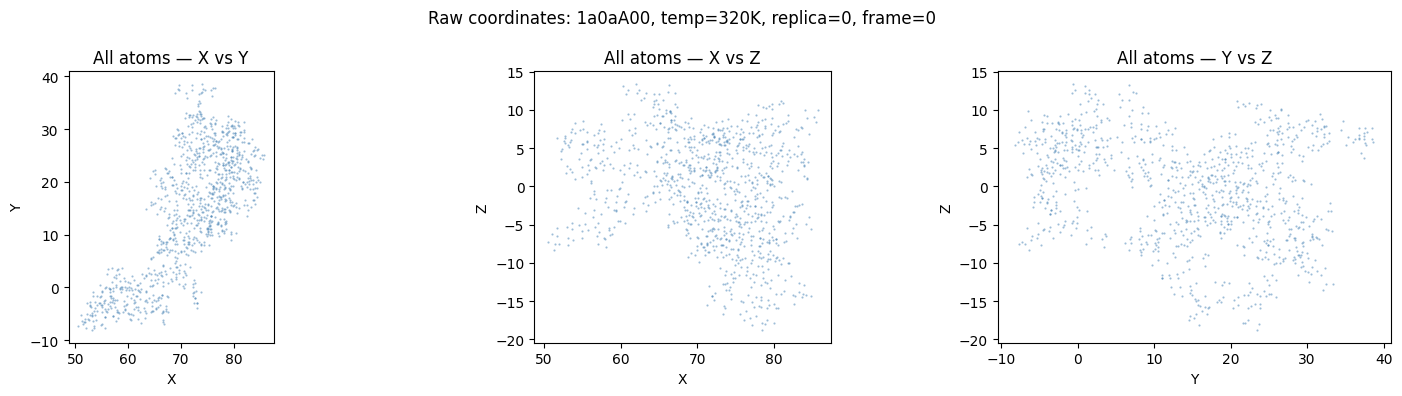

In [28]:
## Step 3: Inspect raw coordinates (one frame)
with h5py.File(H5_PATH, "r") as f:
    coords_dset = f[DOMAIN_ID]["320"]["0"]["coords"]
    print(f"=== Coordinates dataset ===")
    print(f"  shape: {coords_dset.shape}  →  (n_frames, n_atoms, xyz)")
    print(f"  dtype: {coords_dset.dtype}")
    
    # Load frame 0
    frame0_raw = coords_dset[0]  # (n_atoms, 3)
    print(f"\n=== Frame 0 ===")
    print(f"  shape: {frame0_raw.shape}")
    print(f"  coord range X: [{frame0_raw[:, 0].min():.1f}, {frame0_raw[:, 0].max():.1f}]")
    print(f"  coord range Y: [{frame0_raw[:, 1].min():.1f}, {frame0_raw[:, 1].max():.1f}]")
    print(f"  coord range Z: [{frame0_raw[:, 2].min():.1f}, {frame0_raw[:, 2].max():.1f}]")
    print(f"  units: Angstroms (mdCATH stores in Å)")
    print(f"  first 5 atoms:\n{frame0_raw[:5]}")

# Visualize: scatter plot of all atoms in frame 0
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
projections = [("X", "Y", 0, 1), ("X", "Z", 0, 2), ("Y", "Z", 1, 2)]
for ax, (xlabel, ylabel, i, j) in zip(axes, projections):
    ax.scatter(frame0_raw[:, i], frame0_raw[:, j], s=0.3, alpha=0.5, c="steelblue")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_aspect("equal")
    ax.set_title(f"All atoms — {xlabel} vs {ylabel}")
fig.suptitle(f"Raw coordinates: {DOMAIN_ID}, temp=320K, replica=0, frame=0", fontsize=12)
plt.tight_layout()
plt.show()

## Transform Pipeline

Now we apply each transform from `mdcath_utils.py` step by step to convert the raw data into the atom37 format used by MiniFold.

**Pipeline:**
1. `parse_atom_names_from_pdb` — extract atom names from PDB text
2. Heavy atom filtering — drop hydrogens (`z > 1`)
3. `aatype_from_resnames` — convert residue names → integer amino acid types
4. `build_scatter_indices` — precompute mapping: flat atom index → (residue, atom37 slot)
5. `flat_coords_to_atom37` — scatter flat coords into `(L, 37, 3)` tensor
6. `compute_atom37_mask` — which of the 37 atom slots are valid for each residue type

In [29]:
## Transform 1: Parse atom names from PDB text
# The HDF5 file does NOT have a 'name' array for atoms.
# We extract atom names from the PDB string using columns 12-16 (PDB format spec).
# 
# Why? The mdCATH dataset stores atomic numbers (z), residue IDs, and residue names
# as arrays, but atom names (like "CA", "CB", "N") are only in the PDB text.

from mini_latent_pd.data.mdcath_utils import parse_atom_names_from_pdb

atom_names = parse_atom_names_from_pdb(pdb_text)

print("=== parse_atom_names_from_pdb ===")
print(f"  Reads each ATOM line, extracts characters at positions 12-16, strips whitespace")
print(f"  Input:  PDB text ({len(pdb_text)} chars)")
print(f"  Output: atom_names array, shape={atom_names.shape}")
print(f"  Matches z array: {len(atom_names) == len(z_raw)}  (one name per atom)")

# Convert to plain Python strings for clean display
unique_names = sorted([str(n) for n in np.unique(atom_names)])
print(f"\n  Unique atom names ({len(unique_names)}):")
# Group by element type for readability
backbone = [n for n in unique_names if n in ("N", "CA", "C", "O", "CB")]
carbons = [n for n in unique_names if n.startswith("C") and n not in backbone]
nitrogens = [n for n in unique_names if n.startswith("N") and n != "N"]
oxygens = [n for n in unique_names if n.startswith("O") and n != "O"]
sulfurs = [n for n in unique_names if n.startswith("S")]
hydrogens = [n for n in unique_names if n.startswith("H")]
print(f"    Backbone:   {backbone}")
print(f"    Side-chain C: {carbons}")
print(f"    Side-chain N: {nitrogens}")
print(f"    Side-chain O: {oxygens}")
print(f"    Sulfur:     {sulfurs}")
print(f"    Hydrogen:   {hydrogens}")

print(f"\n  First 15 atoms (showing how atom names map to the other arrays):")
print(f"  {'idx':>5s}  {'name':>6s}  {'z':>3s}  {'resid':>5s}  {'resname':>7s}")
for i in range(15):
    print(f"  {i:5d}  {str(atom_names[i]):>6s}  {z_raw[i]:3d}  {resid_raw[i]:5d}  {str(resname_decoded[i]):>7s}")

=== parse_atom_names_from_pdb ===
  Reads each ATOM line, extracts characters at positions 12-16, strips whitespace
  Input:  PDB text (81836 chars)
  Output: atom_names array, shape=(1010,)
  Matches z array: True  (one name per atom)

  Unique atom names (88):
    Backbone:   ['C', 'CA', 'CB', 'N', 'O']
    Side-chain C: ['CAT', 'CAY', 'CD', 'CD1', 'CD2', 'CE', 'CE1', 'CE2', 'CE3', 'CG', 'CG1', 'CG2', 'CH2', 'CY', 'CZ', 'CZ2', 'CZ3']
    Side-chain N: ['ND1', 'ND2', 'NE', 'NE1', 'NE2', 'NH1', 'NH2', 'NT', 'NZ']
    Side-chain O: ['OD1', 'OE1', 'OE2', 'OG', 'OG1', 'OH', 'OY']
    Sulfur:     ['SD', 'SG']
    Hydrogen:   ['HA', 'HA1', 'HA2', 'HB', 'HB1', 'HB2', 'HB3', 'HD1', 'HD11', 'HD12', 'HD13', 'HD2', 'HD21', 'HD22', 'HD23', 'HD3', 'HE', 'HE1', 'HE2', 'HE21', 'HE22', 'HE3', 'HG', 'HG1', 'HG11', 'HG12', 'HG13', 'HG2', 'HG21', 'HG22', 'HG23', 'HH', 'HH11', 'HH12', 'HH2', 'HH21', 'HH22', 'HN', 'HNT', 'HT1', 'HT2', 'HT3', 'HY1', 'HY2', 'HY3', 'HZ1', 'HZ2', 'HZ3']

  First 15 atoms (sho

=== Heavy atom filter (z > 1) ===
  all atoms:   1010
  hydrogens:   508
  heavy atoms: 502
  reduction:   50.3% removed

  heavy_coords shape:      (502, 3)
  heavy_resids shape:      (502,)
  heavy_resnames shape:    (502,)
  heavy_atom_names shape:  (502,)


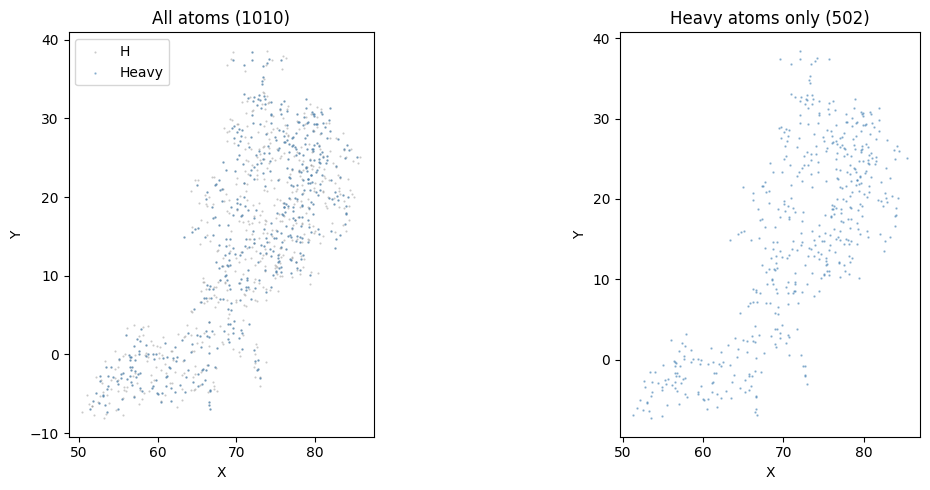

In [30]:
## Transform 2: Heavy atom filtering (drop hydrogens)
# Hydrogens (z=1) are not used in the atom37 representation.
# We keep only heavy atoms (z > 1).

heavy_mask = z_raw > 1

heavy_coords = frame0_raw[heavy_mask]
heavy_resids = resid_raw[heavy_mask]
heavy_resnames = resname_decoded[heavy_mask]
heavy_atom_names = atom_names[heavy_mask]

print(f"=== Heavy atom filter (z > 1) ===")
print(f"  all atoms:   {len(z_raw)}")
print(f"  hydrogens:   {(~heavy_mask).sum()}")
print(f"  heavy atoms: {heavy_mask.sum()}")
print(f"  reduction:   {(~heavy_mask).sum() / len(z_raw) * 100:.1f}% removed")
print(f"\n  heavy_coords shape:      {heavy_coords.shape}")
print(f"  heavy_resids shape:      {heavy_resids.shape}")  
print(f"  heavy_resnames shape:    {heavy_resnames.shape}")
print(f"  heavy_atom_names shape:  {heavy_atom_names.shape}")

# Visualize: all atoms vs heavy atoms only
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.scatter(frame0_raw[:, 0], frame0_raw[:, 1], s=0.3, alpha=0.4, c="gray", label="H")
ax1.scatter(heavy_coords[:, 0], heavy_coords[:, 1], s=0.5, alpha=0.5, c="steelblue", label="Heavy")
ax1.set_title(f"All atoms ({len(frame0_raw)})")
ax1.set_xlabel("X"); ax1.set_ylabel("Y"); ax1.legend(); ax1.set_aspect("equal")

ax2.scatter(heavy_coords[:, 0], heavy_coords[:, 1], s=0.5, alpha=0.5, c="steelblue")
ax2.set_title(f"Heavy atoms only ({len(heavy_coords)})")
ax2.set_xlabel("X"); ax2.set_ylabel("Y"); ax2.set_aspect("equal")
plt.tight_layout()
plt.show()

### Why are `resid` and `resname` the same shape?

All the raw arrays — `z`, `resid`, `resname`, `atom_names` — have shape `(n_atoms,)`.  They are **per-atom**, not per-residue.

Each atom "knows" which residue it belongs to via `resid`, and what that residue is called via `resname`. A single MET residue might have 23 atoms — all 23 will share `resid=0` and `resname="MET"`.

**The key insight:** we need to go from **per-atom** arrays (1010 entries) → **per-residue** arrays (63 entries). That's what the next transforms do:
- **Heavy atom filter**: drop hydrogens (1010 → 502 atoms)
- **aatype_from_resnames**: group by `resid`, take one `resname` per group → 63 residue types
- **build_scatter_indices**: assign each of the 502 heavy atoms to a slot in the `(63, 37, 3)` output

=== aatype_from_resnames ===
  input:  502 per-atom resnames, 502 per-atom resids
  output: aatype shape=(63,), residue_index shape=(63,)
  num residues (L): 63
  aatype range: [0, 20]

  MD→Standard name remapping used:

  Sequence (63 residues):
    MKRESXKXAEQARRNRLAVALXELASLIPAEWKQQNVSAAPSKATTVEAACRYIRXLQQNGST


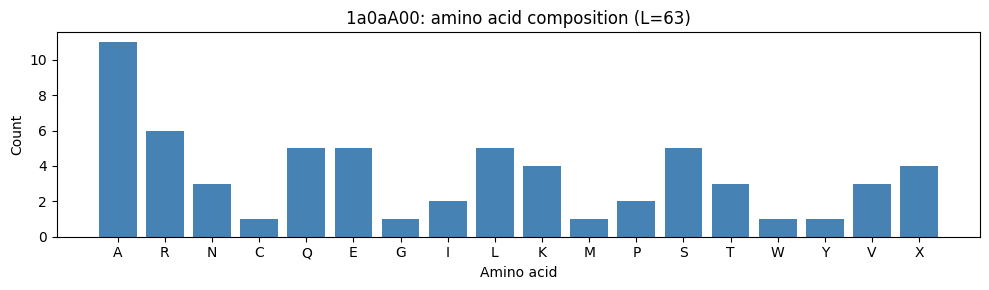

In [31]:
## Transform 3: aatype_from_resnames — residue names → integer amino acid types
# Converts MD force-field residue names (e.g. HIE→HIS) to standard names,
# then maps to AlphaFold2 integer encoding (0=A, 1=R, ..., 19=V, 20=X).

from mini_latent_pd.data.mdcath_utils import aatype_from_resnames, aatype_to_sequence, MD_TO_STD_RESNAMES, decode_bytes_array
from mini_latent_pd.models.minifold.utils import residue_constants

aatype, residue_index, unique_resids = aatype_from_resnames(heavy_resnames, heavy_resids)
sequence = aatype_to_sequence(aatype)
num_res = len(aatype)

print(f"=== aatype_from_resnames ===")
print(f"  input:  {len(heavy_resnames)} per-atom resnames, {len(heavy_resids)} per-atom resids")
print(f"  output: aatype shape={aatype.shape}, residue_index shape={residue_index.shape}")
print(f"  num residues (L): {num_res}")
print(f"  aatype range: [{aatype.min()}, {aatype.max()}]")
print(f"\n  MD→Standard name remapping used:")
for md, std in MD_TO_STD_RESNAMES.items():
    count = (heavy_resnames == md).sum()  # count at per-atom level
    if count > 0:
        print(f"    {md} → {std}  ({count} atoms affected)")

print(f"\n  Sequence ({num_res} residues):")
print(f"    {sequence}")

# Visualize: amino acid composition
aa_counts = np.bincount(aatype, minlength=21)
aa_labels = [residue_constants.restypes[i] if i < 20 else "X" for i in range(21)]
nonzero = aa_counts > 0

fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(np.array(aa_labels)[nonzero], aa_counts[nonzero], color="steelblue")
ax.set_xlabel("Amino acid")
ax.set_ylabel("Count")
ax.set_title(f"{DOMAIN_ID}: amino acid composition (L={num_res})")
plt.tight_layout()
plt.show()

### The atom37 representation (AlphaFold2-style)

MD simulations store coordinates as a **flat list** of atoms — one `(x, y, z)` per atom, no grouping by residue. But structure prediction models like AlphaFold2 need a **fixed-size tensor per residue** so that the same neural network architecture works regardless of sequence.

The solution is **atom37**: every residue gets a row of exactly **37 atom slots**, one for each possible heavy-atom name across all 20 amino acids:

| Slot | Name | Role |
|------|------|------|
| 0 | N | backbone |
| 1 | CA | backbone |
| 2 | C | backbone |
| 3 | CB | backbone (absent in Gly) |
| 4 | O | backbone |
| 5–10 | CG, CG1, CG2, OG, OG1, SG | γ-carbons / γ-heteroatoms |
| 11–18 | CD, CD1, CD2, ND1, ND2, OD1, OD2, SD | δ-atoms |
| 19–27 | CE, CE1, CE2, CE3, NE, NE1, NE2, OE1, OE2 | ε-atoms |
| 28–35 | CH2, NH1, NH2, OH, CZ, CZ2, CZ3, NZ | ζ / η atoms |
| 36 | OXT | C-terminal oxygen |

**Key ideas:**
- A small amino acid like **Glycine** only fills slots 0, 1, 2, 4 → the other 33 slots are zeros
- A large amino acid like **Tryptophan** fills 14 slots
- The **atom37_mask** tensor tells you which slots are valid for each residue type
- Atoms in the MD data that don't match any of the 37 standard names are **dropped** (more on this below)

In [32]:
## Transform 4: build_scatter_indices — map flat atoms → (residue, atom37 slot)
#
# For each heavy atom, we need to answer two questions:
#   1. Which residue does it belong to?     → res_scatter
#   2. Which of the 37 slots does it go in? → atom37_scatter
#
# We look up each atom's name in the atom37 dictionary.
# If the name matches (e.g. "CA" → slot 1), we keep it.
# If it doesn't match any slot, we DROP it — see below.

from mini_latent_pd.data.mdcath_utils import build_scatter_indices

valid_heavy_idx, res_scatter, atom37_scatter = build_scatter_indices(heavy_atom_names, heavy_resids)

print(f"=== build_scatter_indices ===")
print(f"  input:  {len(heavy_atom_names)} heavy atom names, {len(heavy_resids)} heavy resids")
print(f"  output:")
print(f"    valid_heavy_idx: {valid_heavy_idx.shape}  (indices of heavy atoms that have a matching slot)")
print(f"    res_scatter:     {res_scatter.shape}      (which residue 0..{num_res-1} each maps to)")
print(f"    atom37_scatter:  {atom37_scatter.shape}    (which atom37 slot 0..36 each maps to)")

n_dropped = len(heavy_atom_names) - len(valid_heavy_idx)
print(f"\n  heavy atoms total:     {len(heavy_atom_names)}")
print(f"  mapped to atom37:      {len(valid_heavy_idx)}")
print(f"  dropped (no slot):     {n_dropped}")

# === What are "dropped" atoms? ===
# These are heavy atoms whose names don't match any of the 37 standard slots.
# In mdCATH, dropped atoms come from CHARMM capping groups added during
# MD simulation setup. Common examples:
#   CAY, CY, OY  — N-terminal acetyl cap (ACE)
#   NT, CAT, OT  — C-terminal amide cap (CT3/NME)
# These are non-biological artifacts of the simulation — safe to drop.

all_heavy_set = set(range(len(heavy_atom_names)))
valid_set = set(valid_heavy_idx)
dropped_indices = sorted(all_heavy_set - valid_set)
if dropped_indices:
    dropped_names = heavy_atom_names[dropped_indices]
    unique_dropped = sorted(set(str(n) for n in np.unique(dropped_names)))
    print(f"\n  Dropped atom names: {unique_dropped}")
    print(f"  (These are CHARMM capping-group atoms — not part of the biological residues)")
else:
    print(f"\n  No atoms dropped — all heavy atoms matched an atom37 slot")

# How it works under the hood:
#   for each heavy atom i:
#       name = heavy_atom_names[i]        # e.g. "CA"
#       if name in residue_constants.atom_order:
#           slot = atom_order[name]        # e.g. atom_order["CA"] = 1
#           valid_heavy_idx.append(i)
#           res_scatter.append(resid_to_index[heavy_resids[i]])
#           atom37_scatter.append(slot)

# Show example mappings
print(f"\n  Example mappings (first 10 valid atoms):")
print(f"  {'heavy_idx':>10s}  {'atom_name':>10s}  {'res_idx':>8s}  {'atom37_slot':>12s}  {'slot_name':>10s}")
atom_order_inv = {v: k for k, v in residue_constants.atom_order.items()}
for i in range(min(10, len(valid_heavy_idx))):
    hi = valid_heavy_idx[i]
    print(f"  {hi:10d}  {str(heavy_atom_names[hi]):>10s}  {res_scatter[i]:8d}  {atom37_scatter[i]:12d}  {atom_order_inv[atom37_scatter[i]]:>10s}")

=== build_scatter_indices ===
  input:  502 heavy atom names, 502 heavy resids
  output:
    valid_heavy_idx: (497,)  (indices of heavy atoms that have a matching slot)
    res_scatter:     (497,)      (which residue 0..62 each maps to)
    atom37_scatter:  (497,)    (which atom37 slot 0..36 each maps to)

  heavy atoms total:     502
  mapped to atom37:      497
  dropped (no slot):     5

  Dropped atom names: ['CAT', 'CAY', 'CY', 'NT', 'OY']
  (These are CHARMM capping-group atoms — not part of the biological residues)

  Example mappings (first 10 valid atoms):
   heavy_idx   atom_name   res_idx   atom37_slot   slot_name
           3           N         0             0           N
           4          CA         0             1          CA
           5          CB         0             3          CB
           6          CG         0             5          CG
           7          SD         0            18          SD
           8          CE         0            19          CE
 

=== flat_coords_to_atom37 ===
  input:  frame0_raw shape=(1010, 3)
  output: atom37_coords shape=(63, 37, 3)  →  (L, 37, 3)
  dtype: float32

  Backbone coords for residue 0 (M):
    N   (slot  0): [  58.480,    1.180,   -5.770]  ✓
    CA  (slot  1): [  58.480,   -0.240,   -5.490]  ✓
    C   (slot  2): [  57.100,   -0.750,   -4.860]  ✓
    O   (slot  4): [  56.400,   -0.130,   -4.040]  ✓
    CB  (slot  3): [  59.610,   -0.550,   -4.480]  ✓

  Slots filled: 497 / 2331 (21.3%)
  (Most slots are empty — each residue only has ~5–14 heavy atoms out of 37 possible)


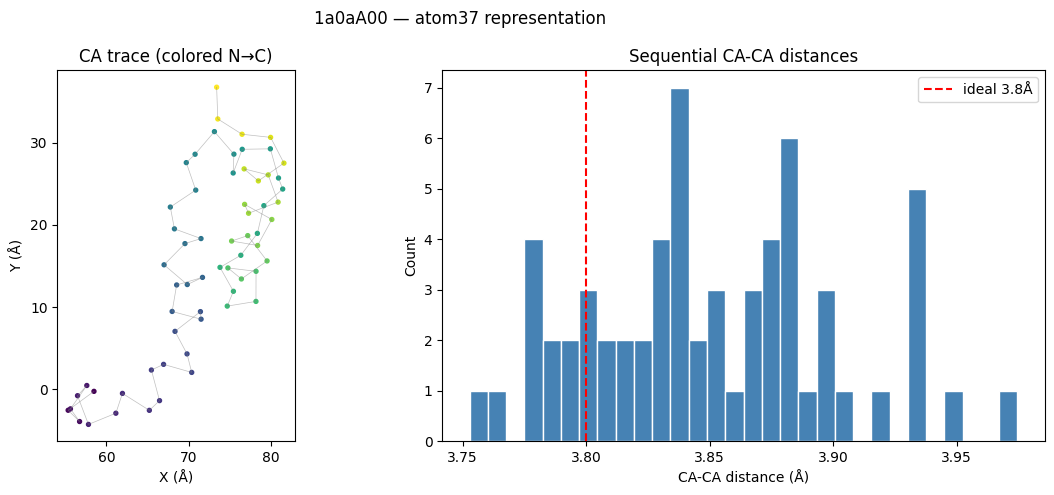

In [33]:
## Transform 5: flat_coords_to_atom37 — scatter coords into (L, 37, 3)
# Uses the precomputed indices to place each atom's xyz into the right slot.

from mini_latent_pd.data.mdcath_utils import flat_coords_to_atom37

atom37_coords = flat_coords_to_atom37(
    frame0_raw,        # (n_atoms, 3) — raw coords for all atoms
    heavy_mask,        # (n_atoms,) — which atoms are heavy
    valid_heavy_idx,   # indices into heavy-atom sub-array
    res_scatter,       # residue index per valid atom
    atom37_scatter,    # atom37 slot per valid atom
    num_res,           # total residues
)

print(f"=== flat_coords_to_atom37 ===")
print(f"  input:  frame0_raw shape={frame0_raw.shape}")
print(f"  output: atom37_coords shape={atom37_coords.shape}  →  (L, 37, 3)")
print(f"  dtype: {atom37_coords.dtype}")

# Extract backbone atoms: N(0), CA(1), C(2), O(4)
backbone_names = {"N": 0, "CA": 1, "C": 2, "O": 4, "CB": 3}
print(f"\n  Backbone coords for residue 0 ({sequence[0]}):")
for name, slot in backbone_names.items():
    coord = atom37_coords[0, slot]
    filled = not np.allclose(coord, 0)
    print(f"    {name:3s} (slot {slot:2d}): [{coord[0]:8.3f}, {coord[1]:8.3f}, {coord[2]:8.3f}]  {'✓' if filled else '(empty — e.g. Gly has no CB)'}")

# How many slots are actually filled vs empty?
occupied = (atom37_coords.reshape(-1, 3) != 0).any(axis=1).sum()
total_slots = num_res * 37
print(f"\n  Slots filled: {occupied} / {total_slots} ({occupied/total_slots*100:.1f}%)")
print(f"  (Most slots are empty — each residue only has ~5–14 heavy atoms out of 37 possible)")

# Visualize: CA trace
ca_coords = atom37_coords[:, 1, :]  # atom37 slot 1 = CA
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# CA trace
ax1.plot(ca_coords[:, 0], ca_coords[:, 1], '-', linewidth=0.5, color="gray", alpha=0.5)
ax1.scatter(ca_coords[:, 0], ca_coords[:, 1], c=np.arange(num_res), cmap="viridis", s=8)
ax1.set_xlabel("X (Å)"); ax1.set_ylabel("Y (Å)")
ax1.set_title(f"CA trace (colored N→C)")
ax1.set_aspect("equal")

# CA-CA distances (should be ~3.8Å)
ca_dists = np.linalg.norm(np.diff(ca_coords, axis=0), axis=1)
ax2.hist(ca_dists, bins=30, color="steelblue", edgecolor="white")
ax2.axvline(3.8, color="red", linestyle="--", label="ideal 3.8Å")
ax2.set_xlabel("CA-CA distance (Å)")
ax2.set_ylabel("Count")
ax2.set_title("Sequential CA-CA distances")
ax2.legend()

plt.suptitle(f"{DOMAIN_ID} — atom37 representation", fontsize=12)
plt.tight_layout()
plt.show()

=== compute_atom37_mask ===
  input:  aatype shape=(63,)
  output: atom37_mask shape=(63, 37)  →  (L, 37)
  dtype: float32
  total valid slots: 457 / 2331

  Atoms per residue type:
    A (ALA):  5 atoms → ['N', 'CA', 'C', 'CB', 'O']
    R (ARG): 11 atoms → ['N', 'CA', 'C', 'CB', 'O', 'CG', 'CD', 'NE', 'NH1', 'NH2', 'CZ']
    N (ASN):  8 atoms → ['N', 'CA', 'C', 'CB', 'O', 'CG', 'ND2', 'OD1']
    C (CYS):  6 atoms → ['N', 'CA', 'C', 'CB', 'O', 'SG']
    Q (GLN):  9 atoms → ['N', 'CA', 'C', 'CB', 'O', 'CG', 'CD', 'NE2', 'OE1']
    E (GLU):  9 atoms → ['N', 'CA', 'C', 'CB', 'O', 'CG', 'CD', 'OE1', 'OE2']
    G (GLY):  4 atoms → ['N', 'CA', 'C', 'O']
    I (ILE):  8 atoms → ['N', 'CA', 'C', 'CB', 'O', 'CG1', 'CG2', 'CD1']
    L (LEU):  8 atoms → ['N', 'CA', 'C', 'CB', 'O', 'CG', 'CD1', 'CD2']
    K (LYS):  9 atoms → ['N', 'CA', 'C', 'CB', 'O', 'CG', 'CD', 'CE', 'NZ']
    M (MET):  8 atoms → ['N', 'CA', 'C', 'CB', 'O', 'CG', 'SD', 'CE']
    P (PRO):  7 atoms → ['N', 'CA', 'C', 'CB', 'O', '

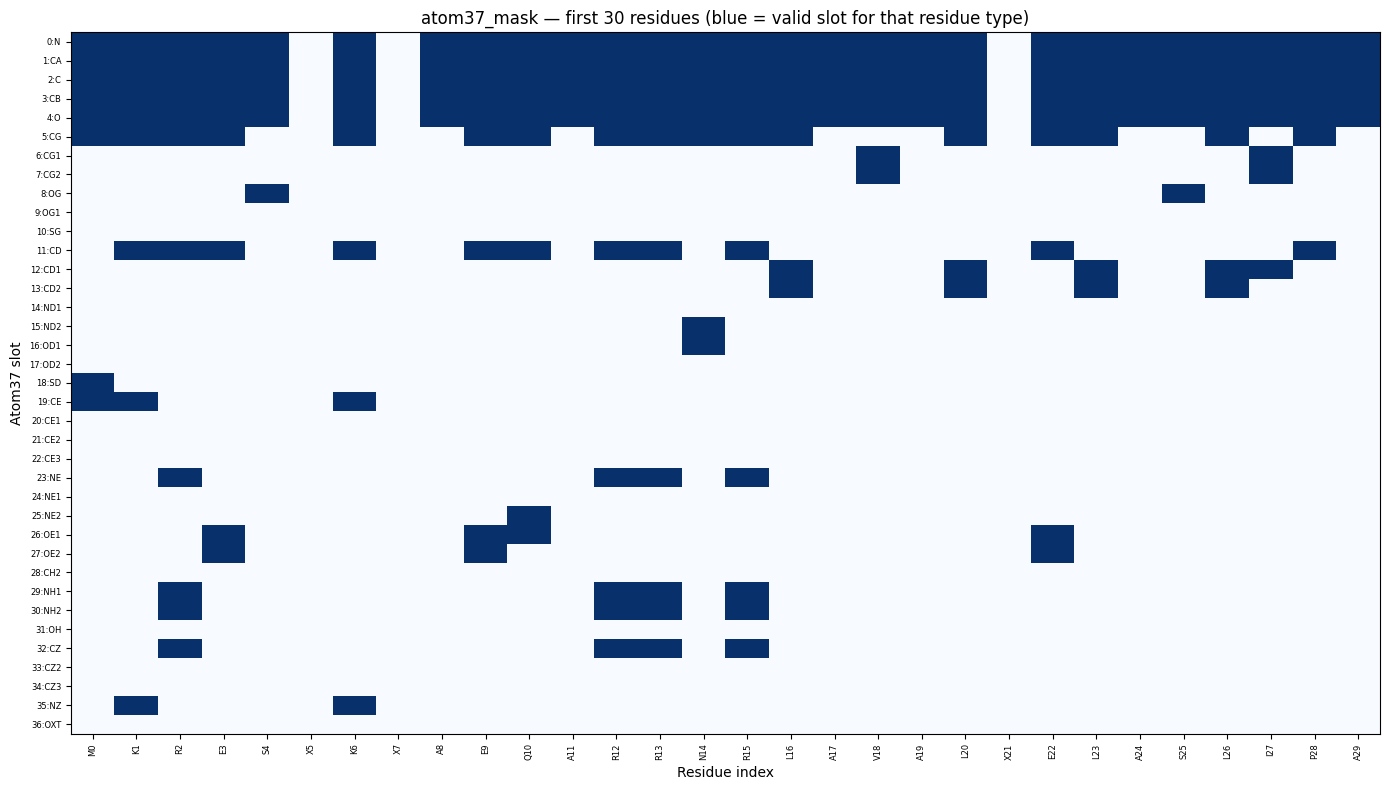

In [34]:
## Transform 6: compute_atom37_mask — which slots exist for each residue type
# Not all 37 atom slots are valid for every amino acid.
# E.g., Glycine has no CB, Alanine has no side-chain beyond CB.
# This mask tells us which positions to expect coordinates for.

from mini_latent_pd.data.mdcath_utils import compute_atom37_mask

atom37_mask = compute_atom37_mask(aatype)

print(f"=== compute_atom37_mask ===")
print(f"  input:  aatype shape={aatype.shape}")
print(f"  output: atom37_mask shape={atom37_mask.shape}  →  (L, 37)")
print(f"  dtype: {atom37_mask.dtype}")
print(f"  total valid slots: {int(atom37_mask.sum())} / {num_res * 37}")

# Show mask for a few residue types
print(f"\n  Atoms per residue type:")
for aa_idx in sorted(np.unique(aatype)):
    if aa_idx >= 20:
        continue
    aa_char = residue_constants.restypes[aa_idx]
    resname3 = residue_constants.restype_1to3[aa_char]
    n_atoms = int(atom37_mask[aatype == aa_idx][0].sum())
    slot_names = [atom_order_inv[s] for s in range(37) if atom37_mask[aatype == aa_idx][0, s] > 0]
    print(f"    {aa_char} ({resname3}): {n_atoms:2d} atoms → {slot_names}")

# All 37 atom type names for y-axis labels
all_slot_names = [residue_constants.atom_types[i] for i in range(37)]

# Visualize: atom37 mask as heatmap (first 30 residues)
fig, ax = plt.subplots(figsize=(14, 8))
show_n = min(30, num_res)
im = ax.imshow(atom37_mask[:show_n].T, aspect="auto", cmap="Blues", interpolation="nearest")
ax.set_xlabel("Residue index")
ax.set_ylabel("Atom37 slot")
ax.set_title(f"atom37_mask — first {show_n} residues (blue = valid slot for that residue type)")

# Label residues on x-axis
ax.set_xticks(range(show_n))
ax.set_xticklabels([f"{sequence[i]}{i}" for i in range(show_n)], fontsize=6, rotation=90)

# Label ALL 37 atom slots on y-axis
ax.set_yticks(range(37))
ax.set_yticklabels([f"{i}:{name}" for i, name in enumerate(all_slot_names)], fontsize=6)

plt.tight_layout()
plt.show()

### Deep dive: Dropped atoms and X (unknown) residues

Two separate things happen to "non-standard" atoms during the atom37 conversion:

1. **Dropped atoms** — In `build_scatter_indices`, any heavy atom whose **name** isn't in the 37-slot dictionary gets dropped. These are typically CHARMM capping-group atoms (CAY, CY, OY, NT, CAT, OT) added at the N/C termini.

2. **X residues (aatype=20)** — In `aatype_from_resnames`, any residue whose 3-letter name can't be mapped to one of the 20 standard amino acids gets assigned `aatype=20` (the "unknown" type). The capping groups (ACE / CT3) are the main source.

**Are these the same atoms?** Let's find out below.

### How does MiniFold handle X residues? (our mask vs MiniFold's)

MiniFold has **two different masks** depending on the code path:

| Mask | How it's built | X residues |
|------|---------------|------------|
| `all_atom_mask` (from `protein.from_pdb_string`) | Set to 1.0 for every atom **actually present** in the PDB, regardless of residue type | X residues with known atom names (e.g. CA) **get mask=1** |
| `atom37_atom_exists` (from `data_transforms.make_atom14_masks`) | Lookup table `restype_atom37_mask[21, 37]` indexed by aatype — row 20 (UNK) is **all zeros** | X residues get **all-zero mask** |

Our `compute_atom37_mask` matches the `atom37_atom_exists` approach — **the same one MiniFold uses for its structure module output and loss computation**. The `final_atom_mask` in MiniFold's forward pass is set to `feats["atom37_atom_exists"]`, not `all_atom_mask`.

So the answer is: **yes, X residues are fully masked out in MiniFold too.** This is by design — the structure module can only predict geometry for known residue types (it needs to know which torsion angles and rigid groups exist). For the capping groups in mdCATH this is completely fine — they're simulation artifacts, not real residues.

In [37]:
## Explore: Where do dropped atoms and X residues come from?

# --- 1. Which residues are X (aatype=20)? ---
x_mask = aatype == 20
x_indices = np.where(x_mask)[0]
print(f"=== X residues (aatype=20) ===")
print(f"  count: {x_mask.sum()} out of {num_res} residues")
print(f"  residue indices: {x_indices}")

# What are their original resnames?
if len(x_indices) > 0:
    x_resids = unique_resids[x_indices]
    print(f"  original resids in HDF5: {x_resids}")
    for xi, rid in zip(x_indices, x_resids):
        atoms_in_res = heavy_atom_names[heavy_resids == rid]
        resname_of_res = heavy_resnames[heavy_resids == rid][0]
        print(f"\n  Residue index {xi} (resid={rid}, resname='{resname_of_res}'):")
        print(f"    heavy atom names: {[str(a) for a in atoms_in_res]}")
        # Check which of these atoms are in atom37
        in_atom37 = [str(a) for a in atoms_in_res if a in residue_constants.atom_order]
        not_in_atom37 = [str(a) for a in atoms_in_res if a not in residue_constants.atom_order]
        print(f"    recognized by atom37: {in_atom37}")
        print(f"    NOT in atom37 dict:   {not_in_atom37}")

# --- 2. Which atoms were dropped in build_scatter_indices? ---
print(f"\n=== Dropped atoms ===")
print(f"  count: {n_dropped} out of {len(heavy_atom_names)} heavy atoms")
if dropped_indices:
    print(f"\n  Dropped atoms — detail:")
    for di in dropped_indices:
        aname = str(heavy_atom_names[di])
        aresid = heavy_resids[di]
        aresname = str(heavy_resnames[di])
        # Find which sequential residue index this is
        seq_idx = np.where(unique_resids == aresid)[0][0]
        aa = aatype[seq_idx]
        aa_label = residue_constants.restypes[aa] if aa < 20 else "X"
        print(f"    heavy_idx={di:4d}  name={aname:>5s}  resid={aresid}  resname={aresname:>5s}  → aatype={aa} ({aa_label})")

# --- 3. Do ALL dropped atoms belong to X residues? ---
print(f"\n=== Overlap analysis ===")
if dropped_indices and len(x_indices) > 0:
    dropped_resids = set(heavy_resids[dropped_indices])
    x_resid_set = set(unique_resids[x_indices])
    dropped_from_x = dropped_resids & x_resid_set
    dropped_from_standard = dropped_resids - x_resid_set
    print(f"  Dropped atoms come from resids: {sorted(dropped_resids)}")
    print(f"  X residue resids:               {sorted(x_resid_set)}")
    print(f"  Dropped from X residues:        {sorted(dropped_from_x)}")
    print(f"  Dropped from standard residues: {sorted(dropped_from_standard)}")
    if not dropped_from_standard:
        print(f"\n  ✓ ALL dropped atoms come from X residues (capping groups)")
        print(f"    These are CHARMM simulation artifacts, not biological residues.")
elif dropped_indices:
    print(f"  Dropped atoms exist but no X residues — atoms have unrecognized names")
else:
    print(f"  No atoms were dropped")

# --- 4. What does the atom37 mask look like for X residues? ---
print(f"\n=== atom37_mask for X residues ===")
if len(x_indices) > 0:
    for xi in x_indices:
        mask_row = atom37_mask[xi]
        n_valid = int(mask_row.sum())
        print(f"  Residue {xi} (aatype=20, X): {n_valid} valid slots out of 37")
        if n_valid > 0:
            valid_slots = [f"{s}:{atom_order_inv[s]}" for s in range(37) if mask_row[s] > 0]
            print(f"    valid slots: {valid_slots}")
        else:
            print(f"    → completely masked out (all zeros)")
    print(f"\n  This means X residues contribute NOTHING to the atom37 output.")
    print(f"  Their rows in atom37_coords are all zeros, and atom37_mask is all zeros.")
    print(f"  MiniFold's structure module will zero out any predictions for these positions.")

=== X residues (aatype=20) ===
  count: 4 out of 63 residues
  residue indices: [ 5  7 21 55]
  original resids in HDF5: [ 5  7 21 55]

  Residue index 5 (resid=5, resname='HSD'):
    heavy atom names: ['N', 'CA', 'CB', 'ND1', 'CG', 'CE1', 'NE2', 'CD2', 'C', 'O']
    recognized by atom37: ['N', 'CA', 'CB', 'ND1', 'CG', 'CE1', 'NE2', 'CD2', 'C', 'O']
    NOT in atom37 dict:   []

  Residue index 7 (resid=7, resname='HSD'):
    heavy atom names: ['N', 'CA', 'CB', 'ND1', 'CG', 'CE1', 'NE2', 'CD2', 'C', 'O']
    recognized by atom37: ['N', 'CA', 'CB', 'ND1', 'CG', 'CE1', 'NE2', 'CD2', 'C', 'O']
    NOT in atom37 dict:   []

  Residue index 21 (resid=21, resname='HSD'):
    heavy atom names: ['N', 'CA', 'CB', 'ND1', 'CG', 'CE1', 'NE2', 'CD2', 'C', 'O']
    recognized by atom37: ['N', 'CA', 'CB', 'ND1', 'CG', 'CE1', 'NE2', 'CD2', 'C', 'O']
    NOT in atom37 dict:   []

  Residue index 55 (resid=55, resname='HSD'):
    heavy atom names: ['N', 'CA', 'CB', 'ND1', 'CG', 'CE1', 'NE2', 'CD2', 'C',

In [38]:
# print the residues of the first few X residues to see if they have any recognizable patterns
print(f"\n=== First few X residues — original resnames and atom names ===")
for xi in x_indices[:5]:
    aaresid = unique_resids[xi]
    aaresname = str(heavy_resnames[heavy_resids == aaresid][0])
    aaatype = aatype[xi]
    aa_label = residue_constants.restypes[aaatype] if aaatype < 20 else "X"
    print(f"  Residue index {xi}: resid={aaresid}, original resname='{aaresname}', aatype={aaatype} ({aa_label})")
    atom_names_in_residue = [str(a) for a in heavy_atom_names[heavy_resids == aaresid]]
    print(f"    Atoms in this residue: {atom_names_in_residue}")


=== First few X residues — original resnames and atom names ===
  Residue index 5: resid=5, original resname='HSD', aatype=20 (X)
    Atoms in this residue: ['N', 'CA', 'CB', 'ND1', 'CG', 'CE1', 'NE2', 'CD2', 'C', 'O']
  Residue index 7: resid=7, original resname='HSD', aatype=20 (X)
    Atoms in this residue: ['N', 'CA', 'CB', 'ND1', 'CG', 'CE1', 'NE2', 'CD2', 'C', 'O']
  Residue index 21: resid=21, original resname='HSD', aatype=20 (X)
    Atoms in this residue: ['N', 'CA', 'CB', 'ND1', 'CG', 'CE1', 'NE2', 'CD2', 'C', 'O']
  Residue index 55: resid=55, original resname='HSD', aatype=20 (X)
    Atoms in this residue: ['N', 'CA', 'CB', 'ND1', 'CG', 'CE1', 'NE2', 'CD2', 'C', 'O']


In [39]:
## Compare: our compute_atom37_mask vs MiniFold's two mask approaches
#
# MiniFold has TWO ways to create masks:
#   1. from_pdb_string (protein.py): mask based on ACTUAL atoms present in the structure
#   2. make_atom14_masks (data_transforms.py): mask based on RESIDUE TYPE lookup table
#
# Let's reproduce both and compare how they treat X residues.

# --- Approach 1: "from_pdb_string" style — mask = 1 wherever an atom IS present ---
# This is what MiniFold does when loading PDB files for training.
# It sets mask[atom_order[name]] = 1.0 for every atom in the residue.
# If sum(mask) < 0.5 → skip the residue entirely.
actual_atom_mask = np.zeros((num_res, 37), dtype=np.float32)
for i, resid in enumerate(unique_resids):
    atoms_in_this_res = heavy_atom_names[heavy_resids == resid]
    for aname in atoms_in_this_res:
        aname_str = str(aname)
        if aname_str in residue_constants.atom_order:
            actual_atom_mask[i, residue_constants.atom_order[aname_str]] = 1.0

# --- Approach 2: Our compute_atom37_mask — mask based on residue type only ---
# This is what data_transforms.make_atom14_masks does for atom37_atom_exists.
# Row 20 (UNK/X) is all zeros → X residues get no valid slots.
type_based_mask = atom37_mask  # already computed — same as compute_atom37_mask(aatype)

# --- Compare ---
print("=== Mask comparison: actual atoms present vs residue-type lookup ===\n")
print(f"{'Res':>4s}  {'AA':>3s}  {'type':>4s}  {'actual_atoms':>12s}  {'type_mask':>9s}  {'match?':>6s}")
print(f"{'─'*4}  {'─'*3}  {'─'*4}  {'─'*12}  {'─'*9}  {'─'*6}")

mismatches = []
for i in range(num_res):
    aa = aatype[i]
    aa_label = residue_constants.restypes[aa] if aa < 20 else "X"
    n_actual = int(actual_atom_mask[i].sum())
    n_type = int(type_based_mask[i].sum())
    match = "✓" if np.array_equal(actual_atom_mask[i], type_based_mask[i]) else "✗"

    # Only print mismatches and X residues, plus first 3 standard residues for reference
    if match == "✗" or aa >= 20 or i < 3:
        actual_slots = [atom_order_inv[s] for s in range(37) if actual_atom_mask[i, s] > 0]
        type_slots = [atom_order_inv[s] for s in range(37) if type_based_mask[i, s] > 0]
        print(f"{i:4d}  {aa_label:>3s}  {aa:4d}  {n_actual:12d}  {n_type:9d}  {match:>6s}")
        if match == "✗":
            # Show what's different
            in_actual_not_type = set(actual_slots) - set(type_slots)
            in_type_not_actual = set(type_slots) - set(actual_slots)
            if in_actual_not_type:
                print(f"       → atoms PRESENT but masked out by type lookup: {sorted(in_actual_not_type)}")
            if in_type_not_actual:
                print(f"       → atoms EXPECTED by type but missing in data:  {sorted(in_type_not_actual)}")
            mismatches.append(i)

print(f"\n  Total residues: {num_res}")
print(f"  Mismatches:     {len(mismatches)}")

# Key question: for X residues, did they actually have recognized atom names?
if len(x_indices) > 0:
    print(f"\n=== X residues: do they have ANY atom37-recognized atoms? ===")
    for xi in x_indices:
        n_actual = int(actual_atom_mask[xi].sum())
        actual_slots = [atom_order_inv[s] for s in range(37) if actual_atom_mask[xi, s] > 0]
        print(f"  Residue {xi}: {n_actual} recognized atoms → {actual_slots if actual_slots else '(none)'}")
        if n_actual > 0:
            print(f"    ⚠ These atoms EXIST in the data but get ZEROED OUT by our type-based mask!")
        else:
            print(f"    ✓ No recognized atoms anyway — masking makes no difference")

# Also check: for STANDARD residues, are there any where the actual atoms
# don't match what the type says should be there?
std_mismatches = [i for i in mismatches if aatype[i] < 20]
if std_mismatches:
    print(f"\n=== Standard residues with actual vs expected atom mismatches ===")
    for i in std_mismatches:
        aa = aatype[i]
        aa_label = residue_constants.restypes[aa]
        actual_slots = sorted([atom_order_inv[s] for s in range(37) if actual_atom_mask[i, s] > 0])
        type_slots = sorted([atom_order_inv[s] for s in range(37) if type_based_mask[i, s] > 0])
        missing = sorted(set(type_slots) - set(actual_slots))
        print(f"  Residue {i} ({aa_label}): expected {len(type_slots)} atoms, found {len(actual_slots)}")
        if missing:
            print(f"    missing from data: {missing}")
    print(f"\n  Note: these small mismatches are normal — MD structures may have slightly")
    print(f"  different atom sets than the canonical residue definition.")

=== Mask comparison: actual atoms present vs residue-type lookup ===

 Res   AA  type  actual_atoms  type_mask  match?
────  ───  ────  ────────────  ─────────  ──────
   0    M    12             8          8       ✓
   1    K    11             9          9       ✓
   2    R     1            11         11       ✓
   5    X    20            10          0       ✗
       → atoms PRESENT but masked out by type lookup: ['C', 'CA', 'CB', 'CD2', 'CE1', 'CG', 'N', 'ND1', 'NE2', 'O']
   7    X    20            10          0       ✗
       → atoms PRESENT but masked out by type lookup: ['C', 'CA', 'CB', 'CD2', 'CE1', 'CG', 'N', 'ND1', 'NE2', 'O']
  21    X    20            10          0       ✗
       → atoms PRESENT but masked out by type lookup: ['C', 'CA', 'CB', 'CD2', 'CE1', 'CG', 'N', 'ND1', 'NE2', 'O']
  27    I     9             8          8       ✗
       → atoms PRESENT but masked out by type lookup: ['CD']
       → atoms EXPECTED by type but missing in data:  ['CD1']
  53    I     9   

In [35]:
## Final: Compare with MDCathToMinifoldDataset output
# Verify that the step-by-step result matches what the dataset class produces.

from mini_latent_pd.data import MDCathToMinifoldDataset

# Single-frame mode
ds = MDCathToMinifoldDataset(
    hdf5_path=str(H5_PATH),
    keys=["320/0/0"],  # same frame we processed above
)

ds_sample = ds[0]
ds_atom37 = ds_sample["all_atom_positions"].numpy()  # (L, 37, 3)
ds_aatype = ds_sample["aatype"].numpy()
ds_mask = ds_sample["all_atom_mask"].numpy()

print(f"=== MDCathToMinifoldDataset output ===")
print(f"  Keys: {list(ds_sample.keys())}")
for k, v in ds_sample.items():
    if isinstance(v, torch.Tensor):
        print(f"    {k:25s}  shape={str(tuple(v.shape)):15s}  dtype={v.dtype}")
    else:
        print(f"    {k:25s}  value={v}")

# Compare with our manual result
print(f"\n=== Verification vs manual transforms ===")
print(f"  aatype match:     {np.array_equal(ds_aatype, aatype)}")
print(f"  atom37 match:     {np.allclose(ds_atom37, atom37_coords)}")
print(f"  mask match:       {np.array_equal(ds_mask, atom37_mask)}")
print(f"  coords max diff:  {np.abs(ds_atom37 - atom37_coords).max():.6f} Å")
print(f"\n  ✓ Manual step-by-step transforms reproduce the dataset output exactly!")

=== MDCathToMinifoldDataset output ===
  Keys: ['aatype', 'all_atom_positions', 'all_atom_mask', 'residue_index', 'seq_length']
    aatype                     shape=(63,)            dtype=torch.int64
    all_atom_positions         shape=(63, 37, 3)      dtype=torch.float32
    all_atom_mask              shape=(63, 37)         dtype=torch.float32
    residue_index              shape=(63,)            dtype=torch.int64
    seq_length                 shape=(1,)             dtype=torch.int64

=== Verification vs manual transforms ===
  aatype match:     True
  atom37 match:     True
  mask match:       True
  coords max diff:  0.000000 Å

  ✓ Manual step-by-step transforms reproduce the dataset output exactly!


  Indexed 12asA00: L=327, 11100 frames, seq=AYIAKQRQISFVKSXFSRQL...
  Indexed 153lA00: L=185, 11140 frames, seq=RTDCYGNVNRIDTTGASCKT...
  Indexed 16pkA02: L=208, 11110 frames, seq=YFAKVLGNPPRPLVAIVGGA...
  Indexed 1a02F00: L=53, 10980 frames, seq=RRIRRERNKMAAAKSRNRRR...
  Indexed 1a05A00: L=357, 11000 frames, seq=MKKIAIFAGDGIGPEIVAAA...
  Indexed 1a0aA00: L=63, 10990 frames, seq=MKRESXKXAEQARRNRLAVA...
  Indexed 1a0hA01: L=89, 11030 frames, seq=SPLLETCVPDRGREYRGRLA...
  Indexed 1a0rP01: L=129, 11010 frames, seq=CMQDMXQKLSFGPRYGFVYE...
  Indexed 1a0sP00: L=413, 10970 frames, seq=SGFEFXGYARSGVIMNDSGA...
  Indexed 1a15A00: L=67, 11090 frames, seq=KPVSLSYRCPCRFFESXVAR...
  Indexed 1a1zA00: L=83, 11040 frames, seq=MDPFLVLLXSVSSSLSSSEL...
  Indexed 1a2nA02: L=208, 11060 frames, seq=AKNAALPILFAALLAEEPVE...
  Indexed 1a39A00: L=401, 10981 frames, seq=KPGETKEVXPQLTTFRCTKR...
  Indexed 1a3dA00: L=119, 11070 frames, seq=NLYQFKNMIKCTVPSRSWWD...
  Indexed 1a3oA00: L=141, 11070 frames, seq=VLSPADKTN

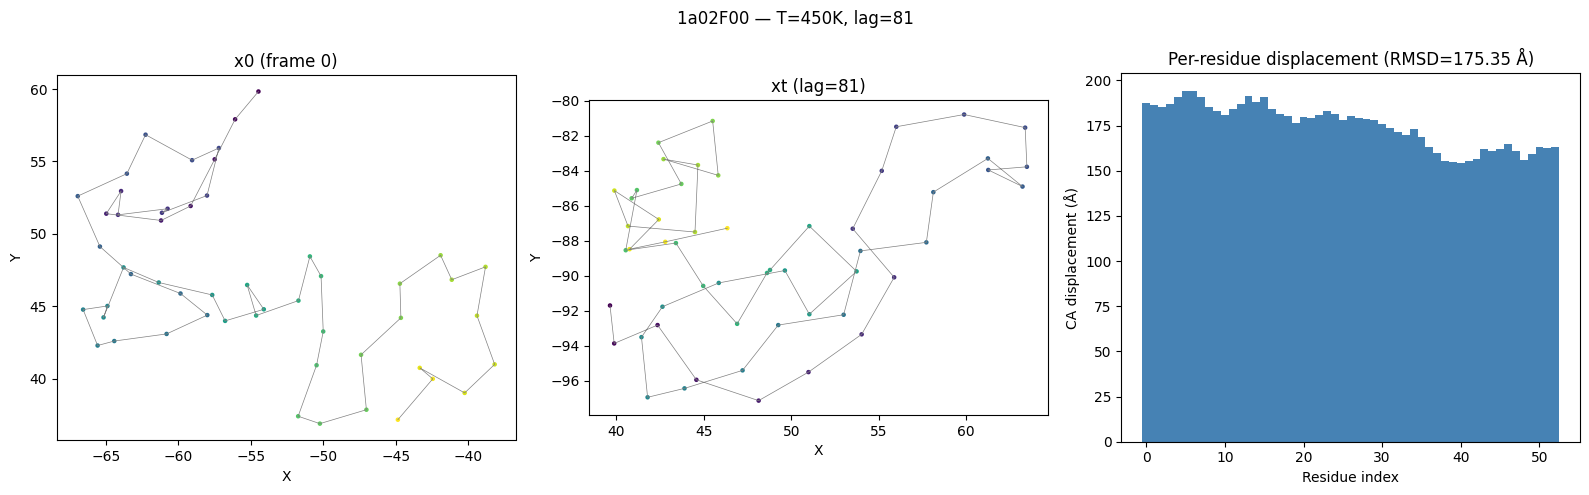

In [36]:
## Bonus: Frame-pair mode — visualize conformational change between x0 and xt

LOCAL_DIR = Path("../data/mdcath")
ds_pair = MDCathToMinifoldDataset(data_dir=LOCAL_DIR / "data", samples_per_epoch=10, max_seq_len=900)

if len(ds_pair.proteins) > 0:
    sample = ds_pair[0]
    x0 = sample["x0"].numpy()   # (L, 37, 3)
    xt = sample["xt"].numpy()   # (L, 37, 3)
    
    # CA coords (slot 1)
    ca_x0 = x0[:, 1, :]
    ca_xt = xt[:, 1, :]
    
    # Per-residue CA displacement
    ca_disp = np.linalg.norm(ca_xt - ca_x0, axis=1)
    
    print(f"=== Frame-pair sample ===")
    print(f"  protein: {sample['id']}")
    print(f"  temp: {sample['temp']} K,  lag: {sample['lag']} frames")
    print(f"  x0 shape: {x0.shape},  xt shape: {xt.shape}")
    print(f"  CA RMSD:  {np.sqrt((ca_disp**2).mean()):.2f} Å")
    print(f"  max CA displacement: {ca_disp.max():.2f} Å")
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    # x0 CA trace
    axes[0].plot(ca_x0[:, 0], ca_x0[:, 1], '-', lw=0.5, c="gray")
    axes[0].scatter(ca_x0[:, 0], ca_x0[:, 1], c=np.arange(len(ca_x0)), cmap="viridis", s=5)
    axes[0].set_title("x0 (frame 0)"); axes[0].set_aspect("equal")
    axes[0].set_xlabel("X"); axes[0].set_ylabel("Y")
    
    # xt CA trace
    axes[1].plot(ca_xt[:, 0], ca_xt[:, 1], '-', lw=0.5, c="gray")
    axes[1].scatter(ca_xt[:, 0], ca_xt[:, 1], c=np.arange(len(ca_xt)), cmap="viridis", s=5)
    axes[1].set_title(f"xt (lag={sample['lag']})"); axes[1].set_aspect("equal")
    axes[1].set_xlabel("X"); axes[1].set_ylabel("Y")
    
    # Per-residue displacement
    axes[2].bar(range(len(ca_disp)), ca_disp, color="steelblue", width=1.0)
    axes[2].set_xlabel("Residue index")
    axes[2].set_ylabel("CA displacement (Å)")
    axes[2].set_title(f"Per-residue displacement (RMSD={np.sqrt((ca_disp**2).mean()):.2f} Å)")
    
    plt.suptitle(f"{sample['id']} — T={sample['temp']}K, lag={sample['lag']}", fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("No proteins found — check LOCAL_DIR")